In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt
import numpy as np

STEP 6 — Dataset Path

In [53]:
dataset_path = "../datasets/PlantVillage"

STEP 7 — Create Image Generator

This automatically:

loads images
resizes images
labels classes

In [54]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

STEP 8 — Load Training Data

In [55]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 16516 images belonging to 14 classes.


STEP 9 — Load Validation Data

In [56]:
val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4122 images belonging to 14 classes.


STEP 10 — Check Classes

In [40]:
print(train_data.class_indices)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato__Target_Spot': 10, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 11, 'Tomato__Tomato_mosaic_virus': 12, 'Tomato_healthy': 13}


STEP 11 — Build CNN Model

In [41]:
model = Sequential([
    
    Conv2D(
        32,#fiter(no.of.filter)so that it can scan 32 pattersn
        (3,3),#filter size
        activation='relu',#to idenfity non linear patterns relu(max,0)
        input_shape=(128,128,3)#imgae h=128,w=128 and rgb color=3
    ),
    
    MaxPooling2D(2,2),#reducing image size means keep imp features
    
    Conv2D(#idetntiy more deeep patterns
        64,# filter incersea from 32 to 64
        (3,3),
        activation='relu'
    ),
    
    MaxPooling2D(2,2),#identiy mode hiiden and deept patters
    
    Conv2D(
        128,#filter increase from 64 to 128
        (3,3),
        activation='relu'
    ),
    
    MaxPooling2D(2,2),
    
    Flatten(), # converting data from 2d to 1d coz dens can take only 1d vector data 
    
    Dense(128, activation='relu'),#make final descion[fully conneted layer] 128 means 128 neurons
    
    Dropout(0.5),#prevent ovefitting
    
    Dense(
        train_data.num_classes,
        activation='softmax'
    )
])

STEP 12 — Compile Model

In [42]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

STEP 13 — Train Model

In [43]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 129s 247ms/step - accuracy: 0.5220 - loss: 1.4834 - val_accuracy: 0.7237 - val_loss: 0.8378
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 141s 273ms/step - accuracy: 0.7163 - loss: 0.8559 - val_accuracy: 0.7948 - val_loss: 0.6093
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 88s 169ms/step - accuracy: 0.7759 - loss: 0.6588 - val_accuracy: 0.8362 - val_loss: 0.4708
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 90s 174ms/step - accuracy: 0.8171 - loss: 0.5395 - val_accuracy: 0.8343 - val_loss: 0.4642
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 89s 172ms/step - accuracy: 0.8467 - loss: 0.4515 - val_accuracy: 0.8695 - val_loss: 0.3768
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 89s 173ms/step - accuracy: 0.8702 - loss: 0.3826 - val_accuracy: 0.8709 - val_loss: 0.3748
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 89s 173ms/step - accuracy: 0.8885 - loss: 0.3279 - val_accuracy: 0.8920 - val_loss: 0.3188
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 89s 173ms/step - accuracy: 0.9020 - loss:

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 403s 390ms/step - accuracy: 0.5362 - loss: 1.0807 - val_accuracy: 0.1855 - val_loss: 2.0025
Epoch 2/8
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 288s 279ms/step - accuracy: 0.5452 - loss: 1.0134 - val_accuracy: 0.1521 - val_loss: 2.5561
Epoch 3/8
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 238s 231ms/step - accuracy: 0.5476 - loss: 0.9698 - val_accuracy: 0.1737 - val_loss: 2.6758
Epoch 4/8
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 274s 265ms/step - accuracy: 0.5530 - loss: 0.9285 - val_accuracy: 0.1535 - val_loss: 2.6211
Epoch 5/8
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 253s 245ms/step - accuracy: 0.5556 - loss: 0.8963 - val_accuracy: 0.1427 - val_loss: 3.4532
Epoch 6/8
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 239s 231ms/step - accuracy: 0.5572 - loss: 0.8674 - val_accuracy: 0.1635 - val_loss: 2.7053
Epoch 7/8
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 254s 246ms/step - accuracy: 0.5596 - loss: 0.8490 - val_accuracy: 0.1422 - val_loss: 3.4849
Epoch 8/8
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 274s 265ms/step - accuracy: 

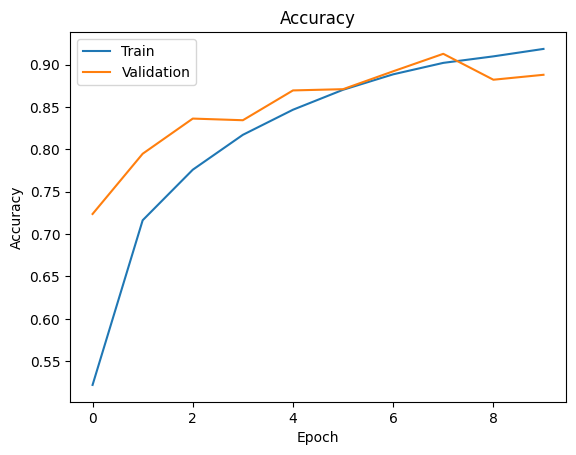

In [44]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [45]:
print(history.history['val_accuracy'])

[0.7236778140068054, 0.7947598099708557, 0.836244523525238, 0.8343037366867065, 0.8694808483123779, 0.8709364533424377, 0.8920426964759827, 0.9126637578010559, 0.8820960521697998, 0.8879184722900391]


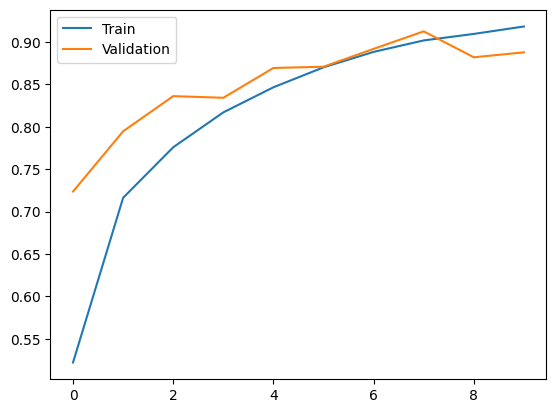

In [47]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train', 'Validation'])

plt.show()

In [48]:
# saving the model so that we can use directly for different project
model.save("plant_disease_detection_model.h5")

In [57]:
# loading the model 

from tensorflow.keras.models import load_model

model = load_model("plant_disease_detection_model.h5")

In [51]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,448 (12.61 MB)

 Trainable params: 3,306,446 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

# WHY WE SAVE CLASS NAMES / LABELS ?

"""
Our CNN model does NOT directly return disease names.

The model only predicts NUMERICAL INDEXES or PROBABILITIES.

Example prediction output:

[0.01, 0.95, 0.04]

This means:
Class 0 → 1%
Class 1 → 95%
Class 2 → 4%

The model predicts:
Highest probability = index 1

BUT the model itself does not know:
index 1 = Tomato___Late_blight

So we must save class labels separately.

Example class mapping:

0 → Tomato___Early_blight
1 → Tomato___Late_blight
2 → Tomato___healthy

During real prediction:

Image
 ↓
CNN predicts index
 ↓
Class labels convert index → disease name
 ↓
Readable result shown to user

Without saving class labels:
Prediction output may only be:
1

and we will not know which disease corresponds to class 1.

Therefore:
.h5 file stores MODEL KNOWLEDGE
class_names.pkl stores CLASS LABEL MAPPING

Both are required for real-world AI prediction systems.
"""

In [52]:
# BEST WAY TO SAVE LABELS

# Use Python pickle.

# Save Labels

import pickle

class_names = list(train_data.class_indices.keys())

with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

In [ ]:
# Later Load Labels
with open("class_names.pkl", "rb") as f:
    class_names = pickle.load(f)

In [58]:
# loading the model 

from tensorflow.keras.models import load_model

model = loa

NameError: name 'loa' is not defined

In [ ]:
# 2. DISEASE DETECTION MODEL

# This model needs:

# IMAGE INPUT

# not numbers.     testing the models working

In [61]:
from tensorflow.keras.preprocessing import image

In [63]:
img = image.load_img(
    r"C:\Users\Shaik Fahad Jahangir\Dropbox\smart ai farming\datasets\PlantVillage\Tomato_healthy\0a0d6a11-ddd6-4dac-8469-d5f65af5afca___RS_HL 0555.JPG",
    target_size=(128,128)
)

In [ ]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0
prediction = model.predict(img_array)
print(prediction)
predicted_class = np.argmax(prediction)
print(predicted_class)
print(class_names[predicted_class])

In [65]:
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [66]:
img_array = img_array / 255.0

In [67]:
prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [68]:
predicted_class = np.argmax(prediction)
print(predicted_class)

7


In [69]:
print(class_names[predicted_class])

Tomato_Late_blight
